# Avaliação do Preditor de Idade do Imóvel - Joinville

Análise completa do modelo treinado para prever a idade de imóveis em Joinville.

In [110]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import sys

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

In [111]:
CIDADE = "joinville"
MES_REF = "2026-09"
PASTA_DADOS = Path("../dados") / CIDADE

ARQUIVO_METADADOS = PASTA_DADOS / f"{CIDADE}_preditor_idade_{MES_REF}.json"
ARQUIVO_MODELO = PASTA_DADOS / f"{CIDADE}_preditor_idade_{MES_REF}.joblib"
ARQUIVO_DADOS = PASTA_DADOS / f"{CIDADE}_imovelweb_{MES_REF}.parquet"

print(f"Metadados: {ARQUIVO_METADADOS}")
print(f"Modelo:    {ARQUIVO_MODELO}")
print(f"Dados:     {ARQUIVO_DADOS}")

Metadados: ..\dados\joinville\joinville_preditor_idade_2026-09.json
Modelo:    ..\dados\joinville\joinville_preditor_idade_2026-09.joblib
Dados:     ..\dados\joinville\joinville_imovelweb_2026-09.parquet


## 1. Carregar Metadados do Modelo

In [112]:
with open(ARQUIVO_METADADOS, "r") as f:
    metadados = json.load(f)

print(f"Modelo: {metadados['modelo']}")
print(f"Treinado em: {metadados['data_treino']}")
print(f"Amostras de treino: {metadados['n_amostras']}")
print(f"Parâmetros otimizados:")
for k, v in metadados["params"].items():
    print(f"  {k}: {v}")
print(f"Métricas CV ({metadados['metricas_cv']['n_folds']} folds, {metadados['metricas_cv']['n_trials']} trials):")
print(f"  RMSE: {metadados['metricas_cv']['rmse']:.2f} anos")
print(f"Métricas Teste:")
print(f"  RMSE:  {metadados['metricas_teste']['rmse']:.2f} anos")
print(f"  MAE:   {metadados['metricas_teste']['mae']:.2f} anos")
print(f"  R²:    {metadados['metricas_teste']['r2']:.3f}")
print(f"  MDAPE: {metadados['metricas_teste']['mdape']:.2f}%")

Modelo: hist_gb
Treinado em: 2026-09-10T00:15:51.841860
Amostras de treino: 4477
Parâmetros otimizados:
  max_iter: 800
  max_depth: 9
  learning_rate: 0.041209922254512275
  min_samples_leaf: 22
  l2_regularization: 3.3966781336261036
Métricas CV (5 folds, 80 trials):
  RMSE: 3.03 anos
Métricas Teste:
  RMSE:  1.00 anos
  MAE:   0.33 anos
  R²:    0.990
  MDAPE: 1.59%


## 2. Carregar Modelo e Dados

In [113]:
modelo = joblib.load(ARQUIVO_MODELO)
print(f"Modelo carregado: {ARQUIVO_MODELO.name}")
print(f"Tipo: {type(modelo).__name__}")

df = pd.read_parquet(ARQUIVO_DADOS)
print(f"Dados brutos: {len(df)} linhas, {len(df.columns)} colunas")

Modelo carregado: joinville_preditor_idade_2026-09.joblib
Tipo: Pipeline
Dados brutos: 10169 linhas, 25 colunas


## 3. Limpar e Preparar Dados

In [114]:
df

,url,titulo,metragem,metragem_total,metragem_util,quartos,suites,banheiros,vagas,idade,...,uf,descricao,data_criacao,caracteristicas,caracteristicas_privativa,caracteristicas_comum,fotos,lat,lng,fonte
0,https://www.imovelweb.com.br/propriedades/flat...,"Flat em Centro, Joinville/SC de 18m² 1 quartos...",18 m²,22 m²,18 m²,1,1,1,None,None,...,SC,Ibis Joinville*Imóvel para investimento (100% ...,2023-12-22T15:41:35Z,[Ar condicionado],[Ar condicionado],[],[https://imgbr.imovelwebcdn.com/avisos/2/29/90...,-26.301034500000000,-48.849762499999997,imovelweb
1,https://www.imovelweb.com.br/propriedades/apar...,"Apartamento em Costa e Silva, Joinville/SC",44 m²,44 m²,44 m²,2,None,1,1,16,...,SC,**Oportunidade de Compra: Apartamento no Bairr...,2026-09-02T03:38:18Z,"[Cozinha Gourmet, TV]","[Cozinha Gourmet, TV]",[],[https://imgbr.imovelwebcdn.com/avisos/2/30/44...,None,None,imovelweb
2,https://www.imovelweb.com.br/propriedades/apar...,"Apartamento à venda em Joinville-SC, no bairro...",45 m²,45 m²,45 m²,1,1,1,1,3,...,SC,Apartamento Loft Giardino no Saguaçu - Residen...,2025-04-01T18:01:58Z,"[Bicicletário, Elevador, Salão de festas, Pisc...","[Piscina, Varanda]","[Bicicletário, Elevador, Salão de festas]",[https://imgbr.imovelwebcdn.com/avisos/resize/...,-26.272374100000000,-48.837289099999999,imovelweb
3,https://www.imovelweb.com.br/propriedades/urba...,Urban Azaléia - Apartamento Pirabeiraba,None,None,None,None,None,None,None,None,...,SC,"Apartamento Pirabeiraba - Urban Azaléia, 2 qua...",2024-04-02T14:22:23Z,"[Bicicletário, Churrasqueira (parrilla), Espaç...",[Ar condicionado],"[Bicicletário, Churrasqueira (parrilla), Espaç...",[https://imgbr.imovelwebcdn.com/avisos/2/29/94...,-26.209039900000000,-48.908440700000000,imovelweb
4,https://www.imovelweb.com.br/propriedades/casa...,"Casa à venda em Joinville-SC, Jardim Paraíso: ...",48 m²,48 m²,48 m²,2,None,1,2,1,...,SC,CASA GEMINADA NO JARDIM PARAÍSO - EXCLUSIVIDAD...,2025-10-21T19:08:40Z,"[Lavanderia, Andares: 1]",[Lavanderia],[],[https://imgbr.imovelwebcdn.com/avisos/2/30/20...,-26.210828800000001,-48.837895299999999,imovelweb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10164,https://www.imovelweb.com.br/propriedades/apar...,"Apartamento com 3 quartos, na Rua Itaiópolis, ...",96 m²,96 m²,None,3,1,2,1,None,...,SC,Venha conhecer este incrível apartamento local...,2026-08-21T14:51:20Z,"[Bicicletário, Churrasqueira (parrilla), Eleva...","[Ar condicionado, Área de serviço, Churrasquei...","[Bicicletário, Churrasqueira (parrilla), Eleva...",[https://imgbr.imovelwebcdn.com/avisos/2/30/43...,-26.304375799999998,-48.846374399999987,imovelweb
10165,https://www.imovelweb.com.br/propriedades/apar...,APARTAMENTO,65 m²,92 m²,65 m²,1,1,2,1,Breve Lançamento,...,SC,[Ver dados]&#Ver dados; Apartamento no Glória ...,2026-03-20T07:10:45Z,"[Bicicletário, Churrasqueira (parrilla), Eleva...",[Mobiliado],"[Bicicletário, Churrasqueira (parrilla), Eleva...",[https://imgbr.imovelwebcdn.com/avisos/2/30/30...,None,None,imovelweb
10166,https://www.imovelweb.com.br/propriedades/apar...,"Apartamento com 2 quartos à venda, 72m² por R$...",72 m²,94 m²,72 m²,2,None,2,1,4,...,SC,CÓDIGO DO IMÓVEL: AP0481. LOCALIZAÇÃO: Apartam...,2026-08-24T18:57:46Z,[Suítes],[Suítes],[],[https://imgbr.imovelwebcdn.com/avisos/2/30/43...,None,None,imovelweb
10167,https://www.imovelweb.com.br/propriedades/apar...,Apartamento com 2 quartos no Saguaçu em Joinville,74 m²,97 m²,74 m²,2,None,1,1,2,...,SC,Localização: Em um dos melhores bairros da cid...,2026-07-17T02:30:26Z,"[Churrasqueira (parrilla), Elevador, Piscina, ...",[],"[Churrasqueira (parrilla), Elevador, Piscina, ...",[https://imgbr.imovelwebcdn.com/avisos/2/30/40...,-26.272941299999999,-48.837045400000000,imovelweb


In [115]:
import re
import unicodedata
from datetime import datetime

sys.path.append("../codigos_rodando")
sys.path.append("../src")
from funcoes_limpando_dados_imoveis import (
    limpar_idade, limpar_metragem, limpar_valor_venda,
    limpar_valor_condominio, limpar_banheiros, limpar_quartos, limpar_vagas,
    converter_para_data, classificar_tipo_imovel, reclassificar_outros,
    limpa_endereco_apply_imovelweb,
)

MAPA_BAIRROS = {
    'pirabeiraba': ['pirabeiraba', 'dona francisca', 'distrito industrial norte'],
    'distrito industrial': ['distrito industrial', 'zona industrial'],
    'area rural': ['area rural', 'rural'],
    'vila nova': ['vila nova'],
    's/b': ['localizacao'],
}

def normalizar_bairros(bairro, mapeamento):
    if not isinstance(bairro, str):
        return bairro
    b = bairro.strip().lower()
    if re.match(r'^\\d+$', b) or b in ('s/n', 's/b', ''):
        return 's/b'
    b_norm = unicodedata.normalize('NFD', b).encode('ascii', 'ignore').decode('utf-8')
    for nome_correto, variacoes in mapeamento.items():
        if any(v in b_norm for v in variacoes):
            return nome_correto
    if 'bairro' in b:
        b = b.split('bairro')[-1].strip(' ,.-')
        if b:
            return b
    return bairro

# Limpeza identica ao script de treino
df['fonte'] = 'imovelweb'
endereco_limpo = df['endereco'].apply(
    lambda x: limpa_endereco_apply_imovelweb(x, 'joinville', 'sc')
)
overlap = set(df.columns) & set(endereco_limpo.columns)
if overlap:
    df = df.drop(columns=list(overlap))
if 'uf' in df.columns and 'estado' in endereco_limpo.columns:
    df = df.drop(columns=['uf'])
df = pd.concat([df, endereco_limpo], axis=1)
if df.columns.duplicated().any():
    df = df.loc[:, ~df.columns.duplicated(keep='last')]

df = df[df['cidade'].isin(['joinville'])]
df = df.drop_duplicates(subset=['url'])
df = df[df['valor_imovel'].notna()]
df = df.dropna(thresh=10)
df = df[df['estado'] == 'sc']

df['metragem'] = df['metragem'].apply(limpar_metragem)
try:
    df['valor_venda'] = df['valor_venda'].apply(limpar_valor_venda)
except Exception:
    df['valor_imovel'] = df['valor_imovel'].apply(limpar_valor_venda)
df['condominio'] = df['condominio'].apply(limpar_valor_condominio)

df['data_criacao'] = df['data_criacao'].apply(converter_para_data)
df['dias_publicacao'] = (
    pd.to_datetime(datetime.now().strftime('%Y-%m-%d'))
    - pd.to_datetime(df['data_criacao'], format='%d/%m/%Y', errors='coerce')
).dt.days

df['banheiros'] = df['banheiros'].apply(limpar_banheiros)
df['quartos'] = df['quartos'].apply(limpar_quartos)
df['vagas'] = df['vagas'].apply(limpar_vagas)
df['idade'] = df['idade'].apply(limpar_idade)

df['tipo_imovel'] = df['titulo'].apply(classificar_tipo_imovel)
mask = df['tipo_imovel'] == 'outros'
df.loc[mask, 'tipo_imovel'] = df.loc[mask, 'descricao'].apply(reclassificar_outros)

df['preco_por_m2'] = df['valor_imovel'] / df['metragem']

for col in ('lat', 'lng'):
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'bairro' in df.columns:
    df['bairro'] = df['bairro'].apply(normalizar_bairros, args=(MAPA_BAIRROS,))
    df['bairro'] = df['bairro'].fillna('desconhecido').astype(str)

df = df.groupby('bairro').filter(lambda x: len(x) > 1)

print(f"Dados limpos: {len(df)} linhas, {len(df.columns)} colunas")
print(f"Colunas: {sorted(df.columns.tolist())}")

features_num = metadados['features_numericas']
features_cat = metadados['features_categoricas']

df['quartos_por_metro'] = df.get('quartos', 0) / df['metragem'].replace(0, np.nan)
df['vagas_por_metro'] = df.get('vagas', 0) / df['metragem'].replace(0, np.nan)

def _normalizar_item(item):
    return item.lower().replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')

def processar_flags(lista, prefixo, flags):
    if not isinstance(lista, list) or len(lista) == 0:
        return {f'{prefixo}_{f}': 0 for f in flags}
    itens_norm = [_normalizar_item(i) for i in lista]
    return {f'{prefixo}_{f}': 1 if f in itens_norm else 0 for f in flags}

CARAC_COMUM_FLAGS = ['elevador', 'piscina', 'churrasqueira_parrilla', 'playground', 'fitness_sala_de_ginastica']
CARAC_PRIVADA_FLAGS = ['varanda', 'lavanderia', 'piscina', 'ar_condicionado']

df['n_carac_comum'] = df['caracteristicas_comum'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df['n_carac_privada'] = df['caracteristicas_privativa'].apply(lambda x: len(x) if isinstance(x, list) else 0)

for idx, row in df.iterrows():
    for flag, val in processar_flags(row.get('caracteristicas_comum', []), 'comum', CARAC_COMUM_FLAGS).items():
        df.at[idx, flag] = val
    for flag, val in processar_flags(row.get('caracteristicas_privativa', []), 'priv', CARAC_PRIVADA_FLAGS).items():
        df.at[idx, flag] = val

for prefixo, flags in [('comum', CARAC_COMUM_FLAGS), ('priv', CARAC_PRIVADA_FLAGS)]:
    for f in flags:
        col = f'{prefixo}_{f}'
        if col in df.columns:
            df[col] = df[col].astype(int)

novas_features = ['n_carac_comum', 'n_carac_privada'] + [f'comum_{f}' for f in CARAC_COMUM_FLAGS] + [f'priv_{f}' for f in CARAC_PRIVADA_FLAGS]
features_num = [f for f in metadados['features_numericas'] if f in df.columns] + [f for f in novas_features if f in df.columns]

df_valid = df.dropna(subset=['idade']).copy()
df_valid['idade'] = df_valid['idade'].astype(float)

all_features = features_num + features_cat

df_valid = df_valid[df_valid['tipo_imovel'].isin(['apartamento', 'casa'])]
#df_valid = df_valid[df_valid['bairro'].isin(['atiradores'])]

X = df_valid[all_features]
df_valid['predicao_idade'] = modelo.predict(X)

df_valid['erro'] = df_valid['idade'] - df_valid['predicao_idade']
df_valid['erro_abs'] = df_valid['erro'].abs()

print(f"Registros com idade válida: {len(df_valid)}")
print(f"Features numéricas ({len(features_num)}): {features_num}")
print(f"Features categóricas ({len(features_cat)}): {features_cat}")

Dados limpos: 10044 linhas, 31 colunas
Colunas: ['bairro', 'banheiros', 'caracteristicas', 'caracteristicas_comum', 'caracteristicas_privativa', 'cep', 'cidade', 'condominio', 'data_criacao', 'descricao', 'dias_publicacao', 'endereco', 'estado', 'fonte', 'fotos', 'idade', 'lat', 'lng', 'metragem', 'metragem_total', 'metragem_util', 'numero', 'preco_por_m2', 'quartos', 'rua', 'suites', 'tipo_imovel', 'titulo', 'url', 'vagas', 'valor_imovel']
Registros com idade válida: 4371
Features numéricas (14): ['metragem', 'quartos', 'banheiros', 'vagas', 'suites', 'lat', 'lng', 'valor_imovel', 'condominio', 'preco_por_m2', 'dias_publicacao', 'quartos_por_metro', 'vagas_por_metro', 'banheiros_por_quarto']
Features categóricas (2): ['bairro', 'tipo_imovel']


## 4. Scatter Plot: Real vs Predito

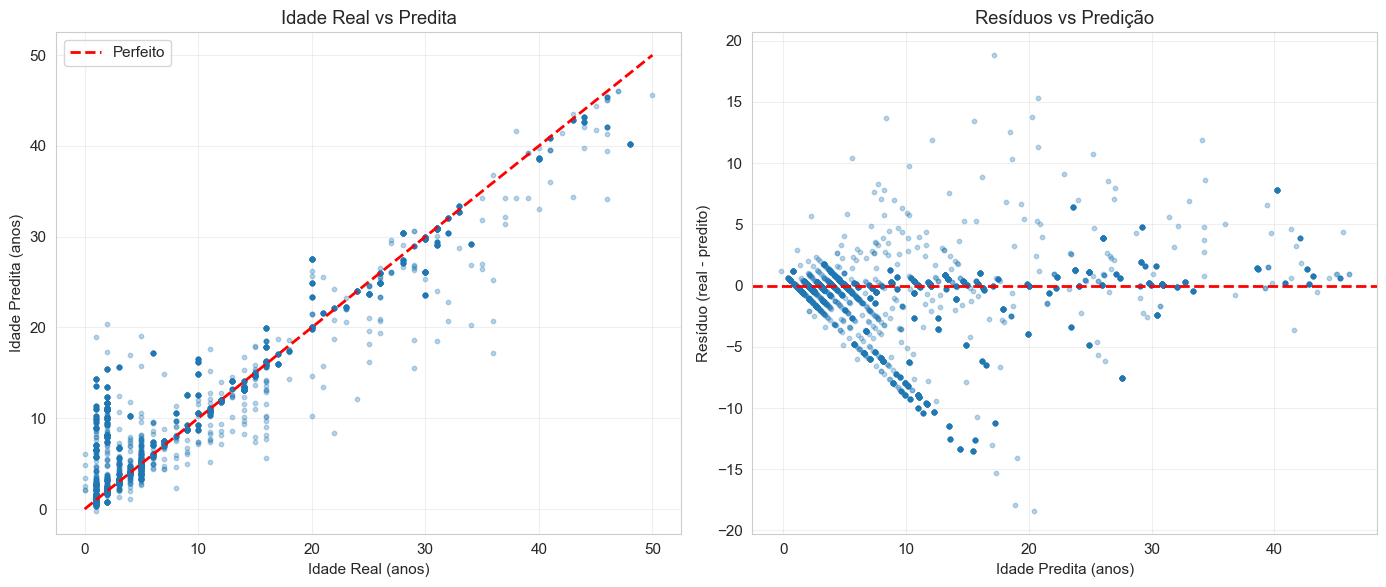

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(df_valid["idade"], df_valid["predicao_idade"], alpha=0.3, s=10)
max_val = max(df_valid["idade"].max(), df_valid["predicao_idade"].max())
axes[0].plot([0, max_val], [0, max_val], "r--", lw=2, label="Perfeito")
axes[0].set_xlabel("Idade Real (anos)")
axes[0].set_ylabel("Idade Predita (anos)")
axes[0].set_title("Idade Real vs Predita")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df_valid["predicao_idade"], df_valid["erro"], alpha=0.3, s=10)
axes[1].axhline(y=0, color="r", linestyle="--", lw=2)
axes[1].set_xlabel("Idade Predita (anos)")
axes[1].set_ylabel("Resíduo (real - predito)")
axes[1].set_title("Resíduos vs Predição")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Histograma de Erros

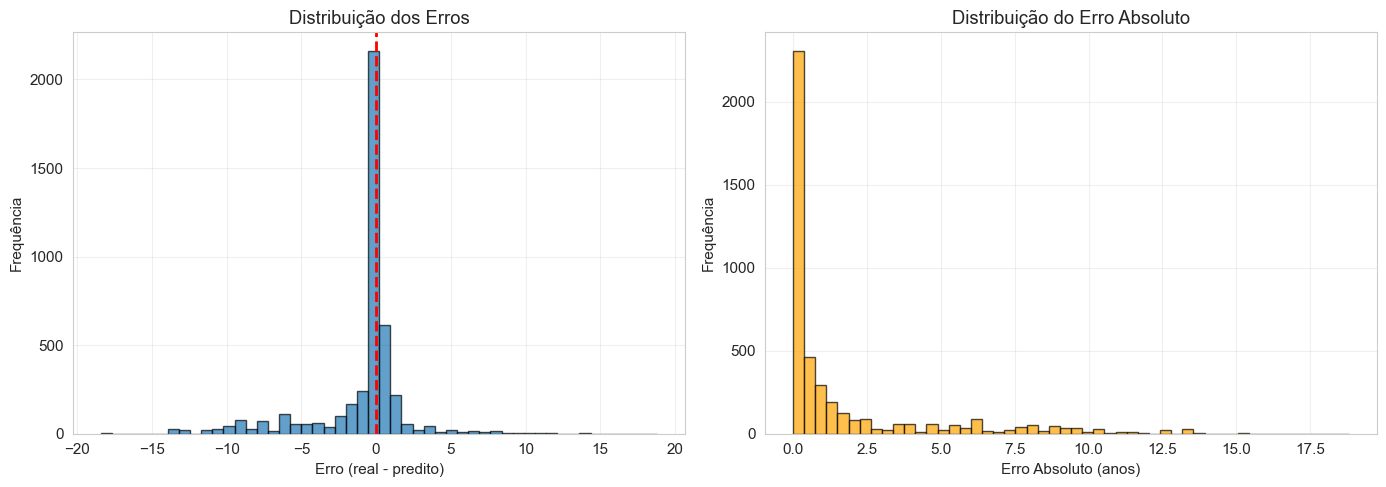

Erro médio: -0.96 anos
Erro absoluto médio: 1.70 anos
Mediana erro absoluto: 0.34 anos
95º percentil erro absoluto: 8.95 anos


In [117]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_valid["erro"], bins=50, edgecolor="black", alpha=0.7)
axes[0].axvline(x=0, color="r", linestyle="--", lw=2)
axes[0].set_xlabel("Erro (real - predito)")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição dos Erros")
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_valid["erro_abs"], bins=50, edgecolor="black", alpha=0.7, color="orange")
axes[1].set_xlabel("Erro Absoluto (anos)")
axes[1].set_ylabel("Frequência")
axes[1].set_title("Distribuição do Erro Absoluto")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Erro médio: {df_valid['erro'].mean():.2f} anos")
print(f"Erro absoluto médio: {df_valid['erro_abs'].mean():.2f} anos")
print(f"Mediana erro absoluto: {df_valid['erro_abs'].median():.2f} anos")
print(f"95º percentil erro absoluto: {df_valid['erro_abs'].quantile(0.95):.2f} anos")

## 6. Métricas por Faixa de Idade

Métricas por faixa de idade:
                  n   rmse    mae      r2  erro_medio
faixa_idade                                          
0-5          2401.0  3.889  1.974 -15.097      -1.854
5-10          682.0  1.936  0.936  -1.098      -0.344
10-20         621.0  2.108  1.205   0.201      -0.182
20-30         309.0  3.114  1.877  -0.024      -0.267
30-50         357.0  3.480  2.033   0.656       1.970
50+             1.0  4.373  4.373     NaN       4.373


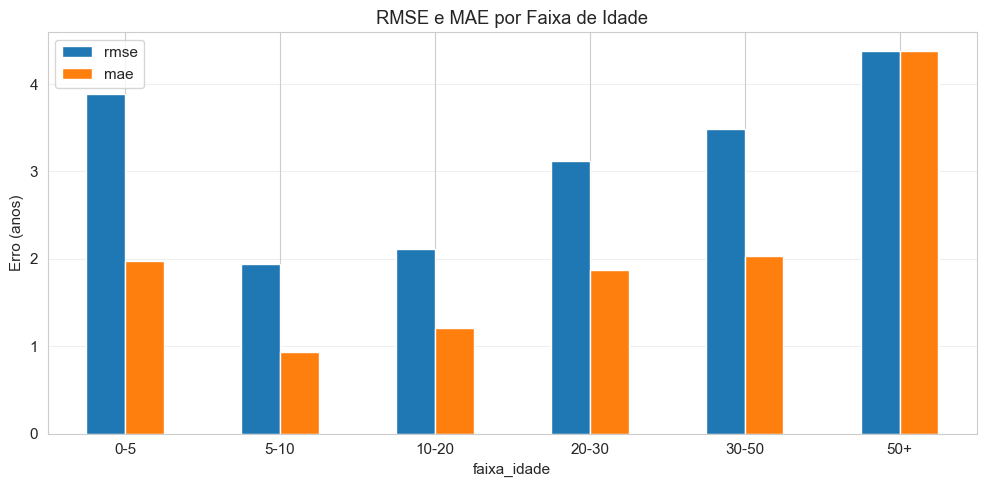

In [118]:
bins = [0, 5, 10, 20, 30, 50, 100]
labels = ["0-5", "5-10", "10-20", "20-30", "30-50", "50+"]
df_valid["faixa_idade"] = pd.cut(df_valid["idade"], bins=bins, labels=labels, right=False)

def calc_rmse(grupo):
    return np.sqrt(mean_squared_error(grupo["idade"], grupo["predicao_idade"]))

metricas_faixa = df_valid.groupby("faixa_idade", observed=True).apply(
    lambda g: pd.Series({
        "n": len(g),
        "rmse": calc_rmse(g),
        "mae": g["erro_abs"].mean(),
        "r2": r2_score(g["idade"], g["predicao_idade"]) if len(g) > 1 else np.nan,
        "erro_medio": g["erro"].mean(),
    })
).round(3)

print("Métricas por faixa de idade:")
print(metricas_faixa.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
metricas_faixa[["rmse", "mae"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Erro (anos)")
ax.set_title("RMSE e MAE por Faixa de Idade")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 7. Análise por Bairro

Bairros com >= 10 registros: 33
Top 10 bairros (menor RMSE):
                         n   rmse    mae  idade_media  predicao_media
bairro                                                               
ulisses guimaraes     19.0  0.307  0.104        1.000           1.036
santa catarina        16.0  0.454  0.366        4.875           4.929
jardim paraiso        33.0  0.523  0.348        4.333           4.057
espinheiros           24.0  0.669  0.618        1.000           0.603
jardim sofia          37.0  0.717  0.457        1.865           2.254
vila nova            125.0  1.232  0.900        7.064           7.465
aventureiro           45.0  1.233  0.643        4.644           4.987
bucarein             137.0  1.242  0.542       12.445          12.541
distrito industrial   12.0  1.456  1.456       40.000          38.544
boa vista            118.0  1.498  0.719       20.864          20.582
Top 10 piores bairros (maior RMSE):
                    n   rmse    mae  idade_media  predicao_medi

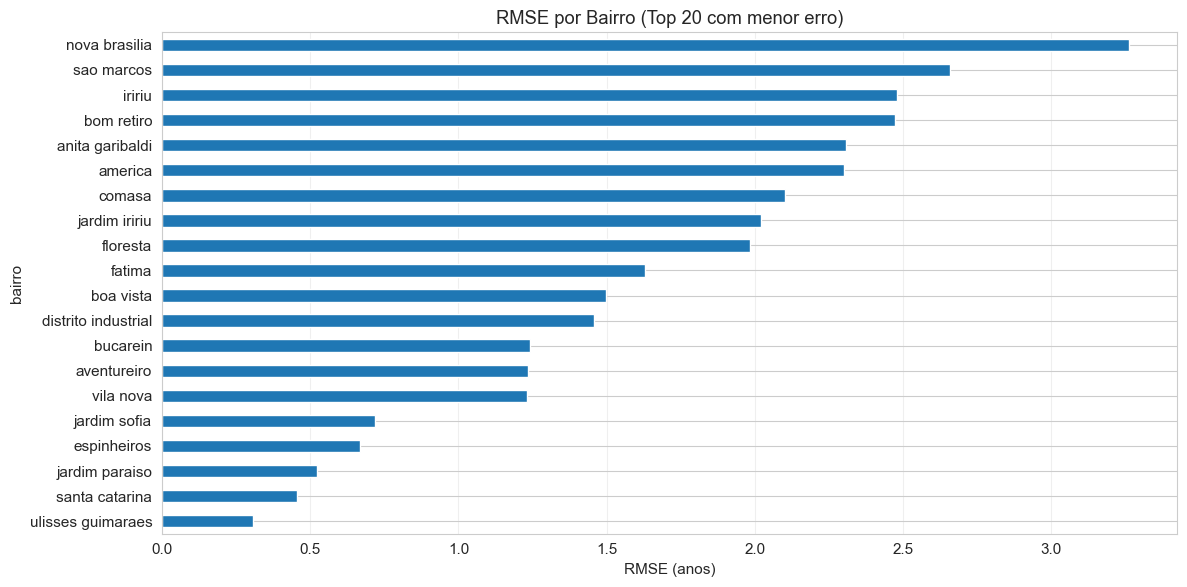

In [119]:
def calc_rmse(grupo):
    return np.sqrt(mean_squared_error(grupo["idade"], grupo["predicao_idade"]))

metricas_bairro = df_valid.groupby("bairro").apply(
    lambda g: pd.Series({
        "n": len(g),
        "rmse": calc_rmse(g),
        "mae": g["erro_abs"].mean(),
        "idade_media": g["idade"].mean(),
        "predicao_media": g["predicao_idade"].mean(),
    })
).round(3)

metricas_bairro = metricas_bairro[metricas_bairro["n"] >= 10]
metricas_bairro = metricas_bairro.sort_values("rmse")

print(f"Bairros com >= 10 registros: {len(metricas_bairro)}")
print(f"Top 10 bairros (menor RMSE):")
print(metricas_bairro.head(10).to_string())
print(f"Top 10 piores bairros (maior RMSE):")
print(metricas_bairro.tail(10).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
metricas_bairro.head(20).plot(kind="barh", y="rmse", ax=ax, legend=False)
ax.set_xlabel("RMSE (anos)")
ax.set_title("RMSE por Bairro (Top 20 com menor erro)")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 8. Top 10 Piores Predições

Top 10 piores predições:

1. Casa com 3 dormitórios à venda, 126 m² por R$ 650.000,00 - N...
   Bairro: nova brasilia | Metragem: 126.0m² | Quartos: 3
   Idade real: 36 anos | Predita: 17.2 anos | Erro: 18.8 anos

2. Residencial Iria e Maria...
   Bairro: itaum | Metragem: 179.0m² | Quartos: 2
   Idade real: 2 anos | Predita: 20.4 anos | Erro: 18.4 anos

3. Apartamento com 2 dormitórios à venda, 86 m² por R$ 380.000,...
   Bairro: sao marcos | Metragem: 86.0m² | Quartos: 2
   Idade real: 1 anos | Predita: 18.9 anos | Erro: 17.9 anos

4. Sobrado de alto padrão 4 quartos à venda, 254m² por R$ R$ 1....
   Bairro: bom retiro | Metragem: 244.0m² | Quartos: 4
   Idade real: 2 anos | Predita: 17.3 anos | Erro: 15.3 anos

5. Casa com 3 dormitórios à venda, 89 m² por R$ 720.000,00 - Co...
   Bairro: costa e silva | Metragem: 89.0m² | Quartos: 3
   Idade real: 36 anos | Predita: 20.7 anos | Erro: 15.3 anos

6. Stuttgart Hause...
   Bairro: anita garibaldi | Metragem: 194.0m² | Quartos: 2
   Idad

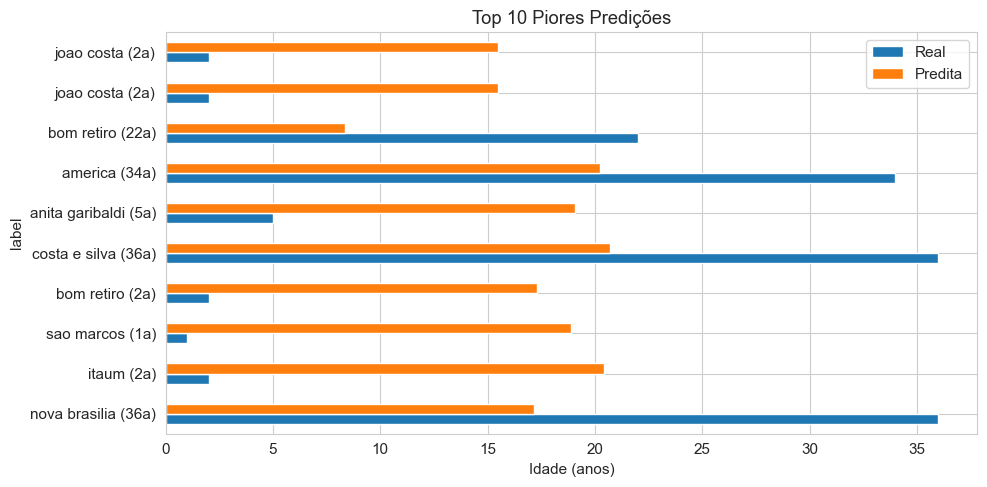

In [120]:
cols_saida = ["titulo", "bairro", "metragem", "quartos", "idade", "predicao_idade", "erro_abs"]
cols_existentes = [c for c in cols_saida if c in df_valid.columns]
piores = df_valid.nlargest(10, "erro_abs")[cols_existentes]

print("Top 10 piores predições:")
for i, (idx, row) in enumerate(piores.iterrows(), 1):
    titulo = str(row.get("titulo", ""))[:60]
    bairro = row.get("bairro", "N/A")
    metragem = row.get("metragem", "N/A")
    quartos = row.get("quartos", "N/A")
    real = row["idade"]
    predita = row["predicao_idade"]
    erro = row["erro_abs"]
    print(f"\n{i}. {titulo}...")
    print(f"   Bairro: {bairro} | Metragem: {metragem}m² | Quartos: {quartos}")
    print(f"   Idade real: {real:.0f} anos | Predita: {predita:.1f} anos | Erro: {erro:.1f} anos")

fig, ax = plt.subplots(figsize=(10, 5))
piores_graf = piores.copy()
piores_graf["label"] = piores_graf.apply(
    lambda r: f"{str(r.get('bairro', ''))[:15]} ({r['idade']:.0f}a)", axis=1
)
piores_graf.plot(kind="barh", x="label", y=["idade", "predicao_idade"], ax=ax)
ax.set_xlabel("Idade (anos)")
ax.set_title("Top 10 Piores Predições")
ax.legend(["Real", "Predita"])
plt.tight_layout()
plt.show()

## 9. Feature Importance

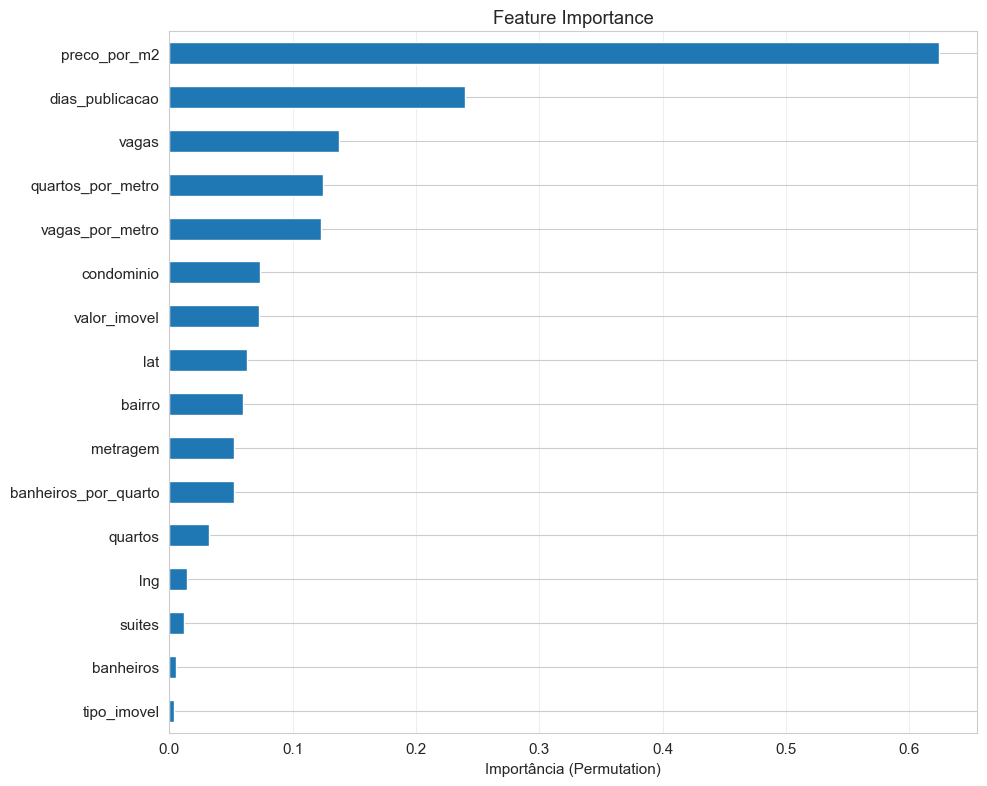

In [121]:
from sklearn.inspection import permutation_importance

result = permutation_importance(modelo, X, df_valid["idade"], n_repeats=10, random_state=42)
importance = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importance.plot(kind="barh", ax=ax)
ax.set_xlabel("Importância (Permutation)")
ax.set_title("Feature Importance")
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 10. QQ Plot e Boxplot dos Resíduos

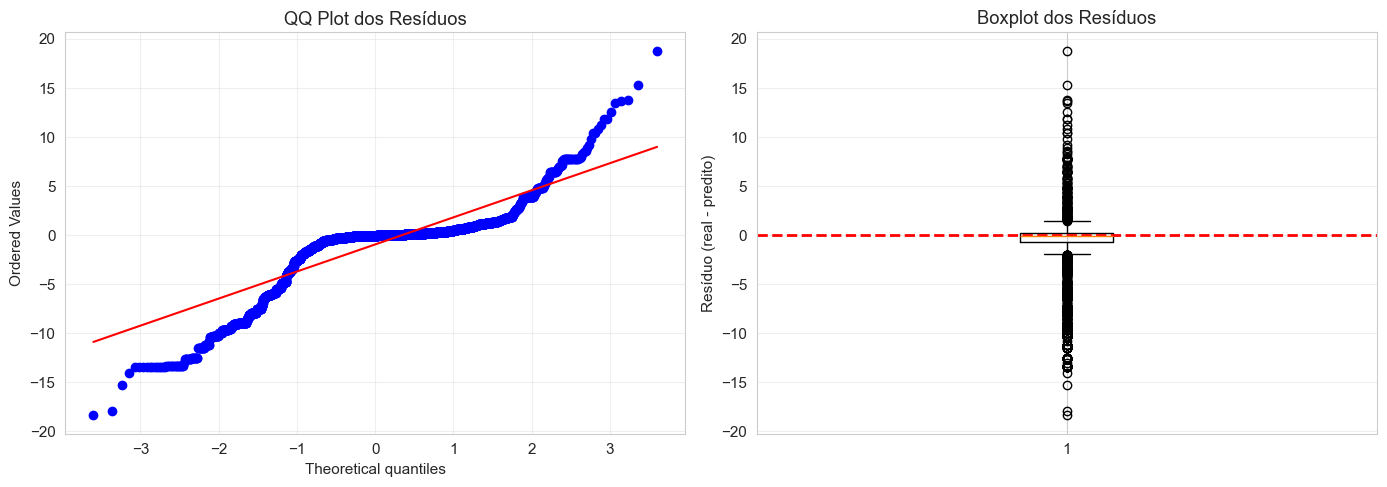

Estatísticas dos resíduos:
  Média: -0.9552
  Mediana: -0.0508
  Desvio padrão: 3.2083
  Assimetria: -1.3656
  Curtose: 4.6403

Teste de Shapiro-Wilk:
  Estatística: 0.7413
  p-value: 0.000000
  Normal: Não (α=0.05)


In [122]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuos = df_valid["erro"].dropna()
stats.probplot(residuos, dist="norm", plot=axes[0])
axes[0].set_title("QQ Plot dos Resíduos")
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(residuos, vert=True)
axes[1].set_ylabel("Resíduo (real - predito)")
axes[1].set_title("Boxplot dos Resíduos")
axes[1].axhline(y=0, color="r", linestyle="--", lw=2)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("Estatísticas dos resíduos:")
print(f"  Média: {residuos.mean():.4f}")
print(f"  Mediana: {residuos.median():.4f}")
print(f"  Desvio padrão: {residuos.std():.4f}")
print(f"  Assimetria: {residuos.skew():.4f}")
print(f"  Curtose: {residuos.kurtosis():.4f}")

stat, p_value = stats.shapiro(residuos.sample(min(5000, len(residuos)), random_state=42))
print(f"\nTeste de Shapiro-Wilk:")
print(f"  Estatística: {stat:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Normal: {'Sim' if p_value > 0.05 else 'Não'} (α=0.05)")

## 11. Resumo Final

In [123]:
rmse_geral = np.sqrt(mean_squared_error(df_valid["idade"], df_valid["predicao_idade"]))
mae_geral = mean_absolute_error(df_valid["idade"], df_valid["predicao_idade"])
r2_geral = r2_score(df_valid["idade"], df_valid["predicao_idade"])

print("=" * 60)
print("RESUMO DA AVALIAÇÃO DO PREDITOR DE IDADE")
print("=" * 60)
print(f"\nModelo: {metadados['modelo']}")
print(f"Treinado em: {metadados['data_treino']}")
print(f"Amostras de treino: {metadados['n_amostras']}")
print(f"\nMétricas no conjunto de validação ({len(df_valid)} registros):")
print(f"  RMSE: {rmse_geral:.2f} anos")
print(f"  MAE:  {mae_geral:.2f} anos")
print(f"  R²:   {r2_geral:.3f}")
print(f"\nDistribuição por faixa:")
print(df_valid["faixa_idade"].value_counts().sort_index().to_string())
print(f"\n{"=" * 60}")

RESUMO DA AVALIAÇÃO DO PREDITOR DE IDADE

Modelo: hist_gb
Treinado em: 2026-09-10T00:15:51.841860
Amostras de treino: 4477

Métricas no conjunto de validação (4371 registros):
  RMSE: 3.35 anos
  MAE:  1.70 anos
  R²:   0.897

Distribuição por faixa:
faixa_idade
0-5      2401
5-10      682
10-20     621
20-30     309
30-50     357
50+         1

